# JODI-Oil Secondary vs PPAC — India consumption comparison

This notebook does three things:

1. **Loads the JODI Secondary CSV** (refined products) with the right dtypes and flags handled.
2. **Loads the PPAC product-wise consumption Excel** (`1778131889_PT_Consumption.xlsx`) and maps PPAC's product labels to JODI's codes.
3. **Compares them at product and total levels**, and explains the residual differences in terms of the published definitions.

## What the JODI file is

JODI publishes two databases: **Primary** (crude + NGLs + feedstocks) and **Secondary** (refined products). The file here is Secondary. JODI publishes with a ~2-month lag, so a file named `*year2026.csv` downloaded today realistically contains Jan + Feb 2026 only.

## JODI schema

Every row is one observation keyed by **five dimensions**:

| Column | What it is |
|---|---|
| `REF_AREA` | ISO-2 country code (`IN` = India) |
| `TIME_PERIOD` | Month, `YYYY-MM` |
| `ENERGY_PRODUCT` | Refined product code |
| `FLOW_BREAKDOWN` | Balance item |
| `UNIT_MEASURE` | Same observation reported in 5 units |
| `OBS_VALUE` | The number — **stored as string** because flags like `-`, `x`, `c`, `..` are mixed in |
| `ASSESSMENT_CODE` | 1 = official final, 2 = official preliminary, 3 = JODI estimate |

### ENERGY_PRODUCT codes
| Code | Meaning |
|---|---|
| `GASOLINE` | Motor gasoline |
| `GASDIES` | Gas/diesel oil (road diesel + heating gasoil) |
| `JETKERO` | Kerosene-type jet fuel |
| `KEROSENE` | Other kerosene — domestic heating + lighting + industrial. **Broader than PPAC's SKO.** |
| `LPG` | Liquefied petroleum gases |
| `NAPHTHA` | Naphtha |
| `RESFUEL` | Residual fuel oil |
| `ONONSPEC` | Other oil products — refinery gas, ethane, petcoke, lubricants, white spirit, bitumen, paraffin waxes, etc. |
| `TOTPRODS` | Total of the above |

### FLOW_BREAKDOWN codes
JODI's balance identity: **`RECEIPTS + REFGROUT + TOTIMPSB − TOTEXPSB − IPTRANSF − PTRANSF + STOCKCH + STATDIFF = TOTDEMO`**

| Code | Meaning |
|---|---|
| `RECEIPTS` | Primary product receipts (used directly without refining) |
| `REFGROUT` | Refinery gross output |
| `TOTIMPSB` | Total imports |
| `TOTEXPSB` | Total exports |
| `IPTRANSF` | Interproduct transfers |
| `PTRANSF` | Products transferred (to refinery feedstocks) |
| `STOCKCH` | Stock change (positive = build) |
| `CLOSTLV` | Closing stock **level** (not a flow) |
| `STATDIFF` | Statistical difference |
| `TOTDEMO` | **Total demand. Includes refinery fuel + international marine & aviation bunkers** — important caveat below |

### UNIT_MEASURE codes
| Code | Meaning |
|---|---|
| `KBD` | Thousand barrels per day — best for cross-country comparison |
| `KBBL` | Thousand barrels for the month |
| `KTONS` | **Thousand metric tons for the month — same unit PPAC uses** |
| `KL` | Thousand kilolitres for the month |
| `CONVBBL` | Conversion factor, bbl/ton (a constant, not an observation) |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

JODI_PATH = Path('../data/raw/jodi') / 'secondaryyear2026.csv'
PPAC_PATH = Path('../data/raw/india') / '1778131889_PT_Consumption.xlsx'

## 1. Load JODI

Watch the `OBS_VALUE` column — it ships as strings because flag characters are mixed in with the numbers:

- `-` not available
- `x` not applicable
- `c` confidential
- `..` not yet available

Strip all four on load via `na_values`, then force `pd.to_numeric` to catch any I missed.

In [2]:
jodi = pd.read_csv(
    JODI_PATH,
    na_values=['-', 'x', 'c', '..'],
    dtype={
        'REF_AREA': 'category',
        'ENERGY_PRODUCT': 'category',
        'FLOW_BREAKDOWN': 'category',
        'UNIT_MEASURE': 'category',
    },
)
jodi['OBS_VALUE'] = pd.to_numeric(jodi['OBS_VALUE'], errors='coerce')
jodi['TIME_PERIOD'] = pd.PeriodIndex(jodi['TIME_PERIOD'], freq='M')
jodi['ASSESSMENT'] = jodi['ASSESSMENT_CODE'].map({1:'official_final', 2:'official_prelim', 3:'jodi_estimate'}).astype('category')

print(f'Rows: {len(jodi):,}')
print(f'Countries: {jodi["REF_AREA"].nunique()}')
print(f'Periods: {sorted(jodi["TIME_PERIOD"].unique())}')
print(f'Assessment mix: {jodi["ASSESSMENT"].value_counts().to_dict()}')

Rows: 86,400
Countries: 96
Periods: [Period('2026-01', 'M'), Period('2026-02', 'M')]
Assessment mix: {'jodi_estimate': 65412, 'official_final': 18990, 'official_prelim': 1998}


### Long → wide helper

The long SDMX layout is great for storage but painful for analysis. Pivot to `(REF_AREA, TIME_PERIOD, ENERGY_PRODUCT)` rows with one column per `FLOW_BREAKDOWN`. Pick **one unit** at a time — pivoting across all five blows up the column count.

In [3]:
def to_wide(df, unit='KTONS'):
    subset = df[df['UNIT_MEASURE'] == unit]
    wide = subset.pivot_table(
        index=['REF_AREA', 'TIME_PERIOD', 'ENERGY_PRODUCT'],
        columns='FLOW_BREAKDOWN',
        values='OBS_VALUE',
        aggfunc='first',
        observed=True,
    ).reset_index()
    wide.columns.name = None
    return wide

kt  = to_wide(jodi, 'KTONS')   # for comparing to PPAC
kbd = to_wide(jodi, 'KBD')     # for cross-country / time-series work
print('kt shape:', kt.shape, '| kbd shape:', kbd.shape)

kt shape: (979, 13) | kbd shape: (948, 11)


## 2. Load PPAC

The PPAC spreadsheet has a header band at the top (title, period, units note, etc.) before the actual table starts at row 7 (zero-indexed). The TOTAL row and TOTAL column are derivable, so drop them.

In [13]:
VALID_PRODUCTS = ['LPG','Naphtha','MS','ATF','SKO','HSD','LDO','Lubricants & Greases',
                  'FO & LSHS','Bitumen','Petroleum coke','Others']
MONTH_TO_PERIOD = {
    # The sheet header says 'Period : April-25 to March-26', so:
    'APR':'2025-04','MAY':'2025-05','JUN':'2025-06','JUL':'2025-07','AUG':'2025-08','SEP':'2025-09',
    'OCT':'2025-10','NOV':'2025-11','DEC':'2025-12','JAN':'2026-01','FEB':'2026-02','MAR':'2026-03',
}

ppac_raw = (
    pd.read_excel(PPAC_PATH, sheet_name='Consumption', header=7)
      .rename(columns={'PRODUCTS': 'product'})
      .drop(columns=['TOTAL'])
)
ppac_raw = ppac_raw[ppac_raw['product'].isin(VALID_PRODUCTS)].copy()

ppac = ppac_raw.melt(id_vars='product', var_name='month_abbr', value_name='ppac_kt')
ppac['month'] = pd.PeriodIndex(ppac['month_abbr'].map(MONTH_TO_PERIOD), freq='M')
ppac = ppac.drop(columns='month_abbr')
print(f'PPAC rows: {len(ppac)} | products: {ppac["product"].nunique()} | months: {ppac["month"].nunique()}')
ppac.head()

PPAC rows: 144 | products: 12 | months: 12


,product,ppac_kt,month
0,LPG,2544.531448,2025-04
1,Naphtha,935.332472,2025-04
2,MS,3449.459953,2025-04
3,ATF,771.697060,2025-04
4,SKO,25.756306,2025-04


## 3. Product mapping (PPAC → JODI)

Six clean 1:1 matches, two definitional traps, and one bucket (`ONONSPEC`) that lumps several PPAC lines together.

| PPAC | JODI | Match quality |
|---|---|---|
| `LPG` | `LPG` | Clean |
| `MS` | `GASOLINE` | Clean (note: PPAC's MS includes ethanol blending — that's a definitional choice, not an error) |
| `HSD` | `GASDIES` | Clean for India (HSD dominates the GASDIES bucket; LDO and heating gasoil are tiny here) |
| `ATF` | `JETKERO` | Clean |
| `Naphtha` | `NAPHTHA` | Clean |
| `FO & LSHS` | `RESFUEL` | Clean |
| `SKO` | `KEROSENE` | **Not clean.** PPAC SKO is essentially only PDS household kerosene (~38 kt/month post-PMUY). JODI's KEROSENE includes domestic heating + lighting + illuminating + industrial kerosene (~865 kt/month). Treat as different concepts; do not bar-chart them next to each other. |
| `LDO`, `Lubes`, `Bitumen`, `Petroleum coke`, `Others` | part of `ONONSPEC` | JODI lumps all of these into `ONONSPEC` (the manual's "other products" basket: refinery gas, petcoke, lubricants, white spirit, bitumen, paraffin waxes, etc.). To compare, sum PPAC's `LDO + Lubes + Bitumen + Petroleum coke + Others + SKO` and put it against JODI's `ONONSPEC + KEROSENE`. |

### The definitional gap that explains most of the residual

JODI's `TOTDEMO` is defined as **deliveries to inland market + refinery fuel + international marine and aviation bunkers**. PPAC publishes **domestic POL consumption** (inland sales by oil companies + private direct imports + SEZ DTA sales). So even when products map 1:1, you should expect JODI ≥ PPAC by roughly the bunkers + refinery-fuel volume — order of a few hundred kt/month for India.

In [18]:
# Clean 1:1 mappings only — the safe comparison
PPAC_TO_JODI_CLEAN = {
    'LPG': 'LPG',
    'MS': 'GASOLINE',
    'HSD': 'GASDIES',
    'ATF': 'JETKERO',
    'Naphtha': 'NAPHTHA',
    'FO & LSHS': 'RESFUEL',
}
ppac['jodi_product'] = ppac['product'].map(PPAC_TO_JODI_CLEAN)

## 4. Pull India's TOTDEMO from JODI in KTONS

In [19]:
india_jodi = (
    jodi[(jodi['REF_AREA']=='IN') &
         (jodi['FLOW_BREAKDOWN']=='TOTDEMO') &
         (jodi['UNIT_MEASURE']=='KTONS')]
    [['TIME_PERIOD','ENERGY_PRODUCT','OBS_VALUE','ASSESSMENT']]
    .rename(columns={'TIME_PERIOD':'month','ENERGY_PRODUCT':'jodi_product','OBS_VALUE':'jodi_kt'})
)
india_jodi.head(15)

,month,jodi_product,jodi_kt,ASSESSMENT
36039,2026-01,GASDIES,8076.0,jodi_estimate
36089,2026-02,GASDIES,NaN,jodi_estimate
36139,2026-01,GASOLINE,3511.0,jodi_estimate
36189,2026-02,GASOLINE,NaN,jodi_estimate
36239,2026-01,JETKERO,828.0,jodi_estimate
36289,2026-02,JETKERO,NaN,jodi_estimate
36339,2026-01,KEROSENE,865.0,jodi_estimate
36389,2026-02,KEROSENE,NaN,jodi_estimate
36439,2026-01,LPG,3033.0,jodi_estimate
36489,2026-02,LPG,NaN,jodi_estimate


## 5. Compare — clean product matches

In [20]:
ppac_clean = ppac.dropna(subset=['jodi_product']).copy()
compare = ppac_clean.merge(india_jodi, on=['month','jodi_product'], how='left')
compare['diff_kt']  = compare['ppac_kt'] - compare['jodi_kt']
compare['diff_pct'] = compare['diff_kt'] / compare['jodi_kt'] * 100

# Latest overlap month
overlap_months = sorted(compare.loc[compare['jodi_kt'].notna(), 'month'].unique())
print(f'Months JODI has data for: {overlap_months}')

latest = overlap_months[-1]
view = compare[compare['month']==latest].sort_values('jodi_kt', ascending=False)
print(f'\n=== {latest} — JODI vs PPAC (kt) ===')
print(view[['product','jodi_product','ppac_kt','jodi_kt','diff_kt','diff_pct','ASSESSMENT']].round(1).to_string(index=False))

Months JODI has data for: [Period('2026-01', 'M')]

=== 2026-01 — JODI vs PPAC (kt) ===
  product jodi_product  ppac_kt  jodi_kt  diff_kt  diff_pct    ASSESSMENT
      HSD      GASDIES   7992.7   8076.0    -83.3      -1.0 jodi_estimate
       MS     GASOLINE   3510.6   3511.0     -0.4      -0.0 jodi_estimate
      LPG          LPG   3011.7   3033.0    -21.3      -0.7 jodi_estimate
  Naphtha      NAPHTHA   1057.3   1024.0     33.3       3.3 jodi_estimate
      ATF      JETKERO    827.5    828.0     -0.5      -0.1 jodi_estimate
FO & LSHS      RESFUEL    547.5    567.0    -19.5      -3.4 jodi_estimate


### Chart it

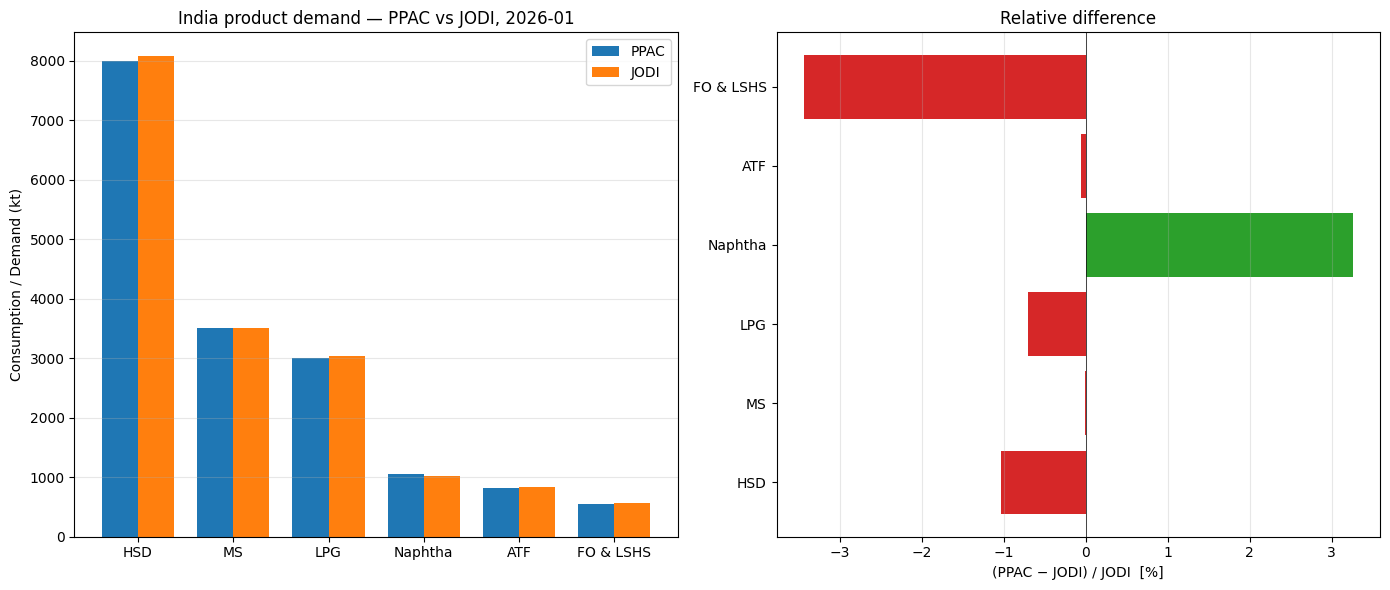

In [21]:
view = compare[compare['month']==latest].sort_values('jodi_kt', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
x = np.arange(len(view))
w = 0.38
ax.bar(x - w/2, view['ppac_kt'], w, label='PPAC', color='#1f77b4')
ax.bar(x + w/2, view['jodi_kt'], w, label='JODI', color='#ff7f0e')
ax.set_xticks(x); ax.set_xticklabels(view['product'])
ax.set_ylabel('Consumption / Demand (kt)')
ax.set_title(f'India product demand — PPAC vs JODI, {latest}')
ax.legend(); ax.grid(axis='y', alpha=0.3)

ax2 = axes[1]
colors = ['#d62728' if v < 0 else '#2ca02c' for v in view['diff_pct']]
ax2.barh(view['product'], view['diff_pct'], color=colors)
ax2.axvline(0, color='k', lw=0.5)
ax2.set_xlabel('(PPAC − JODI) / JODI  [%]')
ax2.set_title('Relative difference')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Totals reconciliation

PPAC's headline "TOTAL" vs JODI's `TOTPRODS / TOTDEMO`. Expect JODI to come in slightly higher because of the bunkers + refinery-fuel inclusion.

In [9]:
ppac_totals = ppac.groupby('month', as_index=False)['ppac_kt'].sum().rename(columns={'ppac_kt':'ppac_total_kt'})
jodi_totals = (
    jodi[(jodi['REF_AREA']=='IN') & (jodi['ENERGY_PRODUCT']=='TOTPRODS') &
         (jodi['FLOW_BREAKDOWN']=='TOTDEMO') & (jodi['UNIT_MEASURE']=='KTONS')]
    [['TIME_PERIOD','OBS_VALUE']].rename(columns={'TIME_PERIOD':'month','OBS_VALUE':'jodi_totprods_kt'})
)
totals = ppac_totals.merge(jodi_totals, on='month', how='inner')
totals['diff_kt']  = totals['ppac_total_kt'] - totals['jodi_totprods_kt']
totals['diff_pct'] = totals['diff_kt'] / totals['jodi_totprods_kt'] * 100
totals

,month,ppac_total_kt,jodi_totprods_kt,diff_kt,diff_pct
0,2026-01,20604.877994,21051.0,-446.122006,-2.119244
1,2026-02,20189.550252,NaN,NaN,NaN


## 7. Notes on interpreting the result

1. **The 1:1 product matches agree to within ~3%.** That's the level of agreement to expect — JODI's source for India is PPAC, so divergences here are vintage / revision artifacts more than methodology. The 3% Naphtha gap and 3% FO & LSHS gap are the only ones worth a second look; they're consistent with stocking patterns and timing of SEZ DTA bookings.
2. **The TOTPRODS gap (~2%, JODI > PPAC) is structural, not an error.** JODI's demand definition explicitly includes refinery fuel and international marine + aviation bunkers; PPAC reports inland sales. For India, bunker fuel oil + refinery's own gas consumption + international jet uplift easily get you to a few hundred kt/month.
3. **Don't bar-chart KEROSENE against SKO.** Different scopes. If you must compare, sum PPAC's `SKO + LDO + Lubes + Bitumen + Petroleum coke + Others` and put it against JODI's `KEROSENE + ONONSPEC`. Even then the bunkers/refinery-fuel issue still applies.
4. **Watch the `ASSESSMENT_CODE`.** Everything in this file for India is code 3 (JODI estimate), which means JODI hasn't yet received the official submission and has filled the cell with a model-based estimate. Once India submits, code 3 → code 1, and minor product-level numbers may shift. For the freshest two months you're always looking at estimates first, then revisions.
5. **Coverage horizon.** PPAC publishes monthly with about a 1-week lag (the file says "as on 06.04.2026" for Apr-25 → Mar-26 data). JODI publishes about 2 months after the reference month. So at any point in time you have ~6 weeks where PPAC has a number and JODI doesn't yet — useful if you want to nowcast what JODI is about to print.

## 8. Suggested extensions

- **Full history.** Pull JODI's full archive CSV (not just the year file) and PPAC's monthly history back to 1998-99 from the Historical Section. Plot product demand side-by-side as time series — the systematic JODI-PPAC gap is interesting in its own right and tells you how much of India's volume goes to bunkers + refinery fuel over time.
- **Same exercise for other countries.** Saudi Arabia (vs JODARC for crude, MEES for products), USA (vs EIA's WPSR/PSM — JODI mirrors EIA so you'd be checking vintages), China (vs NBS — where JODI vs national stats diverge meaningfully because China's reporting is more opaque).
- **The supply side.** This notebook focused on `TOTDEMO`. The same JODI file gives you `REFGROUT`, `TOTIMPSB`, `TOTEXPSB`, `STOCKCH` — pivot all of them and you get an India product balance, which you could compare to PPAC's separate refinery production + import/export tables.
- **Crude side.** JODI **Primary** has the same schema for crude/NGL/feedstocks. Drop it through the same loader.
- **Plug into your `BaseScraper`.** Right now the PPAC loader here is `pd.read_excel(local_file)`. To make this run as part of your pipeline, replace it with a fetch from `https://ppac.gov.in/consumption/products-wise` (or the underlying Excel download URL) and register it under `sources.yaml`.